/home/sadilek/Dev/mesaplus/mesapdk-lab/.venv/lib/python3.13/site-packages/kfactory/decorators.py:406: UserWarning: `width` overrides `start_width`. Use only `start_width` going forward.
  cell = f(**params)  # type: ignore[call-arg]


['AL0_0', 'AL0_1']
['AL1_0', 'AL1_1']
['AL3_0', 'AL3_1']
Info(die_frame={'die_clean_size': (20000.0, 10000.0), 'die_polished_bbox': (-10000.0, -5000.0, 10000.0, 5000.0), 'die_step_size': (20045.0, 10045.0), 'die_step_bbox': (-10022.5, -5022.5, 10022.5, 5022.5), 'die_velist_size': (20045.0, 10045.0), 'die_velist_bbox': (-10022.5, -5022.5, 10022.5, 5022.5), 'polish_widths': {'N': 0.0, 'S': 0.0, 'W': 0.0, 'E': 0.0}, 'polish_sides': [], 'dicing_width': 45.0}, polish_ruler={'pr_span_min': -100.0, 'pr_span_max': 100.0, 'pr_span_tuple': (100.0, -100.0), 'pr_edge': 'Left', 'pr_resolution': 5.0, 'pr_main_div': 10, 'pr_num_div': 2, 'pr_height': 50.0, 'pr_tick_width': 1.0, 'pr_extra_center': True, 'pr_bbox_enabled': True, 'pr_bbox_frame': True, 'pr_layer': 'WG', 'pr_bbox_layer': 'FLOORPLAN', 'pr_size_x': 219.0, 'pr_size_y': 69.0, 'pr_origin_x': 0.0, 'pr_origin_y': 0.0}, fiber_arrays=[{'fa_axis': 'y', 'fa_pitch': 127.0, 'fa_n_channels': 32, 'fa_centered': True, 'fa_alignment_n_loops': 3, 'fa_align

/home/sadilek/Dev/mesaplus/mesapdk-lab/.venv/lib/python3.13/site-packages/gdsfactory/components/bends/bend_euler.py:110: UserWarning: {'width': 2.5} ignored for cross_section 'xs_24911e99'
  x = gf.get_cross_section(cross_section, width=width or x.width)


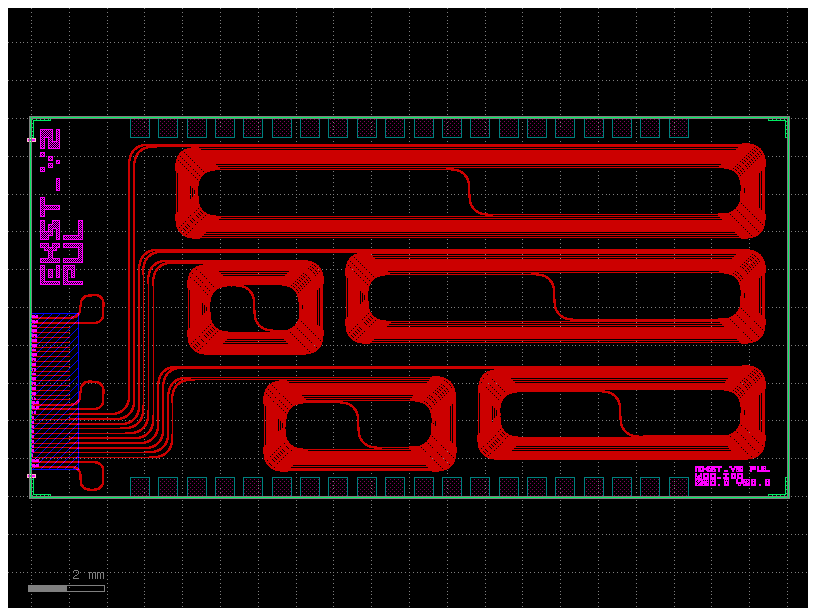

In [1]:
from EKST_v2_PUL import ekst_v2_pul_master

my_die = ekst_v2_pul_master()

my_die.plot()

24


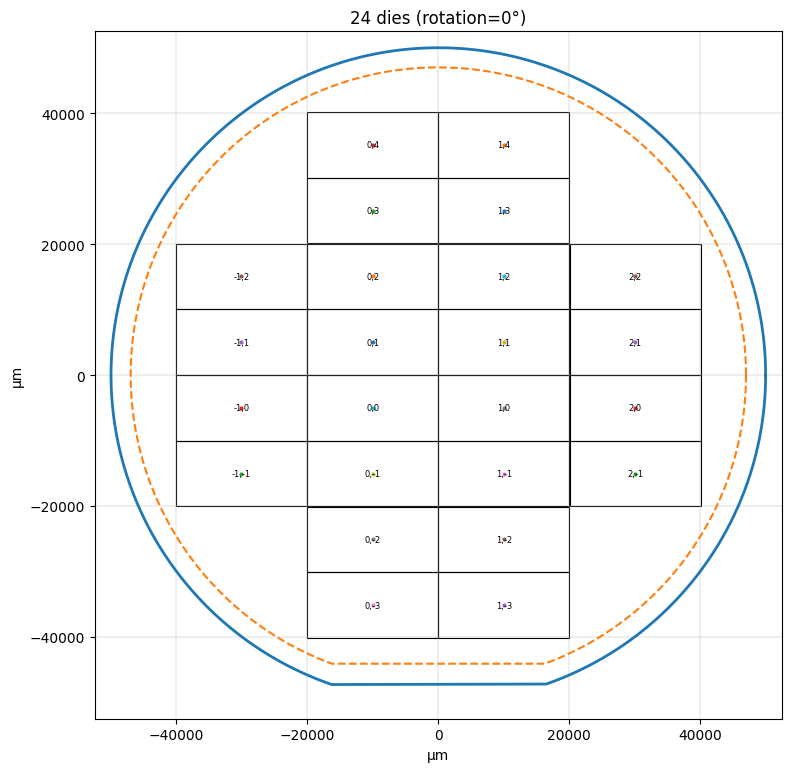

DiePackingResult(die_clean_size=(20000.0, 10000.0), die_step_size=(20045.0, 10045.0), wafer=WaferSpec(name='100mm', diameter_um=100000.0, edge_exclusion_um=3000, primary_flat_um=32500.0, secondary_flat_um=None, secondary_flat_angle_deg=None, notch_radius_um=None, notch_center_from_origin_um=None), usable_wafer=WaferSpec(name='100mm_usable', diameter_um=94000.0, edge_exclusion_um=0.0, primary_flat_um=32500.0, secondary_flat_um=None, secondary_flat_angle_deg=None, notch_radius_um=None, notch_center_from_origin_um=None), rotation=0, count=24, centers=[(-30067.5, -15067.5), (-30067.5, -5022.5), (-30067.5, 5022.5), (-30067.5, 15067.5), (-10022.5, -35157.5), (-10022.5, -25112.5), (-10022.5, -15067.5), (-10022.5, -5022.5), (-10022.5, 5022.5), (-10022.5, 15067.5), (-10022.5, 25112.5), (-10022.5, 35157.5), (10022.5, -35157.5), (10022.5, -25112.5), (10022.5, -15067.5), (10022.5, -5022.5), (10022.5, 5022.5), (10022.5, 15067.5), (10022.5, 25112.5), (10022.5, 35157.5), (30067.5, -15067.5), (30067.5

In [2]:
from helpers import wafer_spec 
from helpers.die_estimator import estimate_max_dies_on_wafer, plot_die_packing

wafer = wafer_spec.make_semi_wafer_spec("100mm", edge_exclusion_um=3000, use_secondary_flat=False)

result = estimate_max_dies_on_wafer(
    die=my_die,
    wafer=wafer,
    allow_rotation=True,
    offset_samples=11,
)

print(result.count)
plot_die_packing(result, show_centers=True, show_indices=True)
print(result)

In [3]:
from EKST_v2_BRT import ekst_v2_brt_master
from EKST_v2_PUL import ekst_v2_pul_master

from ekin_master_die import edge_coupler_array_ekn_def_butt, edge_coupler_array_ekn_def_butt_3loops, edge_coupler_array_ekn_def_centerskip

import gdsfactory as gf


In [4]:
BRT_TAP = gf.partial(ekst_v2_brt_master,ext_grp_spacing=127, label = "EKST_v2\nBRT TAP")
BRT_BUT = gf.partial(ekst_v2_brt_master,ext_grp_spacing=127, ec_array_def=edge_coupler_array_ekn_def_butt, label = "EKST_v2\nBRT BUT")

In [5]:
# BRT_BUT().plot()
# BRT_TAP().plot()

In [6]:
widths = (0.75, 1, 1.25, 1.5)

PUL_TAP_DEF=[]

for i in range(0, len(widths)):
    PUL_TAP_DEF.append(gf.partial(ekst_v2_pul_master, width = (widths[i],), label="EKST_v2\nPUL TAP"))

PUL_BUT_DEF=[]

for i in range(0, len(widths)):
    PUL_BUT_DEF.append(gf.partial(ekst_v2_pul_master, width = (widths[i],),ec_array_def=edge_coupler_array_ekn_def_butt_3loops, label="EKST_v2\nPUL BUT"))



# for pul in PUL_TAP_DEF:
#     pul().plot()

# for pul in PUL_BUT_DEF:
#     pul().plot()

MMWG_BUT = gf.partial(ekst_v2_brt_master, bend_rads=(2000,1000), widths=(2,4,6,8,2,4,6,8,2,4,6,8),ext_grp_spacing=512, label="EKST_v2\nMMWG", ec_array_def=edge_coupler_array_ekn_def_centerskip)

#MMWG_BUT().plot()


In [7]:
from wafer_component import wafer_from_spec

c = wafer_from_spec(wafer=wafer)
c.show()

In [8]:
result.get_center((0,0))

(-10022.5, -5022.5)

In [9]:
assign_array = result.index_map.copy()
assign_array


{
    (0, -3): (-10022.5, -35157.5),
    (1, -3): (10022.5, -35157.5),
    (0, -2): (-10022.5, -25112.5),
    (1, -2): (10022.5, -25112.5),
    (-1, -1): (-30067.5, -15067.5),
    (0, -1): (-10022.5, -15067.5),
    (1, -1): (10022.5, -15067.5),
    (2, -1): (30067.5, -15067.5),
    (-1, 0): (-30067.5, -5022.5),
    (0, 0): (-10022.5, -5022.5),
    (1, 0): (10022.5, -5022.5),
    (2, 0): (30067.5, -5022.5),
    (-1, 1): (-30067.5, 5022.5),
    (0, 1): (-10022.5, 5022.5),
    (1, 1): (10022.5, 5022.5),
    (2, 1): (30067.5, 5022.5),
    (-1, 2): (-30067.5, 15067.5),
    (0, 2): (-10022.5, 15067.5),
    (1, 2): (10022.5, 15067.5),
    (2, 2): (30067.5, 15067.5),
    (0, 3): (-10022.5, 25112.5),
    (1, 3): (10022.5, 25112.5),
    (0, 4): (-10022.5, 35157.5),
    (1, 4): (10022.5, 35157.5)
}

In [10]:
for key in assign_array.keys():
    print("assign_array[{}] = MMWG_BUT".format(key))

assign_array[(0, -3)] = MMWG_BUT
assign_array[(1, -3)] = MMWG_BUT
assign_array[(0, -2)] = MMWG_BUT
assign_array[(1, -2)] = MMWG_BUT
assign_array[(-1, -1)] = MMWG_BUT
assign_array[(0, -1)] = MMWG_BUT
assign_array[(1, -1)] = MMWG_BUT
assign_array[(2, -1)] = MMWG_BUT
assign_array[(-1, 0)] = MMWG_BUT
assign_array[(0, 0)] = MMWG_BUT
assign_array[(1, 0)] = MMWG_BUT
assign_array[(2, 0)] = MMWG_BUT
assign_array[(-1, 1)] = MMWG_BUT
assign_array[(0, 1)] = MMWG_BUT
assign_array[(1, 1)] = MMWG_BUT
assign_array[(2, 1)] = MMWG_BUT
assign_array[(-1, 2)] = MMWG_BUT
assign_array[(0, 2)] = MMWG_BUT
assign_array[(1, 2)] = MMWG_BUT
assign_array[(2, 2)] = MMWG_BUT
assign_array[(0, 3)] = MMWG_BUT
assign_array[(1, 3)] = MMWG_BUT
assign_array[(0, 4)] = MMWG_BUT
assign_array[(1, 4)] = MMWG_BUT


In [11]:
assign_array[(0, -3)] = PUL_BUT_DEF[3]
assign_array[(1, -3)] = PUL_BUT_DEF[2]
assign_array[(0, -2)] = PUL_BUT_DEF[1]
assign_array[(1, -2)] = PUL_BUT_DEF[0]
assign_array[(-1, -1)] = PUL_TAP_DEF[0]
assign_array[(0, -1)] = MMWG_BUT
assign_array[(1, -1)] = MMWG_BUT
assign_array[(2, -1)] = PUL_TAP_DEF[3]
assign_array[(-1, 0)] = PUL_TAP_DEF[1]
assign_array[(0, 0)] = BRT_BUT
assign_array[(1, 0)] = BRT_TAP
assign_array[(2, 0)] = PUL_TAP_DEF[2]
assign_array[(-1, 1)] = PUL_TAP_DEF[2]
assign_array[(0, 1)] = BRT_TAP
assign_array[(1, 1)] = BRT_BUT
assign_array[(2, 1)] = PUL_TAP_DEF[1]
assign_array[(-1, 2)] = PUL_TAP_DEF[3]
assign_array[(0, 2)] = MMWG_BUT
assign_array[(1, 2)] = MMWG_BUT
assign_array[(2, 2)] = PUL_TAP_DEF[0]
assign_array[(0, 3)] = PUL_BUT_DEF[0]
assign_array[(1, 3)] = PUL_BUT_DEF[1]
assign_array[(0, 4)] = PUL_BUT_DEF[2]
assign_array[(1, 4)] = PUL_BUT_DEF[3]

In [12]:
assign_array


{
    (0, -3): functools.partial(<function ekst_v2_pul_master at 0x7c64f8072c00>, width=(1.5,), ec_array_def=functools.partial(<function edge_coupler_array at 0x7c646b6a5120>, edge_coupler=functools.partial(<function butt_ec_with_anchor at 0x7c646b6a4f40>, xs_waveguide=<function xs_ekn300_te_IMGREV at 0x7c646b6a58a0>, cleave_marker_layer=(10, 0)), alignment_coupler=functools.partial(<function two_stage_inverse_taper_with_anchor at 0x7c646b6a4e00>, xs_waveguide=<function xs_ekn300_te_IMGREV at 0x7c646b6a58a0>, cleave_marker_layer=(10, 0)), n=32, n_alignment_loops=0, alignment_pairs={'0': 0, '1': 30, '3': 12}, adhesive_keepout_layer='TE', adhesive_keepout_margin=(250, 50), adhesive_keepout_axis='x', axis_reflection=False, widths=(0.75, 1, 1.25, 1.5), text=functools.partial(<function text_rectangular at 0x7c646b767b00>, layer='GE')), label='EKST_v2\nPUL BUT'),
    (1, -3): functools.partial(<function ekst_v2_pul_master at 0x7c64f8072c00>, width=(1.25,), ec_array_def=functools.partial(<fu

In [13]:
wafer_ID = "W00"

In [14]:
c.locked = False

die_name = ("{}_I{}_{}\nX{:.1f} Y{:.1f}".format(wafer_ID, 0, 0, float(result.get_center((0,0))[0])/1000, float(result.get_center((0,0))[1])/1000))
a = assign_array[(0,0)](chip_id_label = die_name)
a.show()

result.get_center((0,0))

for die in assign_array:
    if assign_array[die] !=None:
        die_name = ("{}_I{}_{}\nX{:.1f} Y{:.1f}".format(wafer_ID, die[0], die[1], float(result.get_center(die)[0])/1000, float(result.get_center(die)[1])/1000))
        dieref = c.add_ref(assign_array[die](chip_id_label = die_name))
        dieref.dmove(origin=(0,0), destination=result.get_center(die))

[DPort(self.name='W01_1o2', self.width=0.75, trans=r0 *1 -9000,-3964.5, layer=WG (1/0), port_type=optical), DPort(self.name='W01_2o2', self.width=1.0, trans=r0 *1 -9000,-3837.5, layer=WG (1/0), port_type=optical), DPort(self.name='W01_3o2', self.width=1.25, trans=r0 *1 -9000,-3710.5, layer=WG (1/0), port_type=optical), DPort(self.name='W01_4o2', self.width=1.5, trans=r0 *1 -9000,-3583.5, layer=WG (1/0), port_type=optical), DPort(self.name='W01_5o2', self.width=0.75, trans=r0 *1 -9000,-3456.5, layer=WG (1/0), port_type=optical), DPort(self.name='W01_6o2', self.width=1.0, trans=r0 *1 -9000,-3329.5, layer=WG (1/0), port_type=optical), DPort(self.name='W01_7o2', self.width=1.25, trans=r0 *1 -9000,-3202.5, layer=WG (1/0), port_type=optical), DPort(self.name='W01_8o2', self.width=1.5, trans=r0 *1 -9000,-3075.5, layer=WG (1/0), port_type=optical), DPort(self.name='W01_9o2', self.width=0.75, trans=r0 *1 -9000,-2948.5, layer=WG (1/0), port_type=optical), DPort(self.name='W01_10o2', self.width=1

In [15]:
c.show()